# Hyperparameter Tuning for BiLSTM and Char-CNN Models

This notebook automates the hyperparameter tuning process for the BiLSTM (teacher) and Char-CNN (student) models. It evaluates the impact of key hyperparameters on model performance and visualizes the results.

In [ ]:
import itertools
import logging
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from train_models import (
    Model1_BiLSTM,
    Model2_CharCNN,
    train_classifier_epoch,
    evaluate_classifier,
    train_student_epoch,
    evaluate_student,
    collate_pair_sequences,
    collate_word_profiles,
    PairSequenceDataset,
    WordProfileDataset,
    resolve_data_path,
    validate_required_columns,
    build_tokenizer_from_pairs,
)
from torch.utils.data import DataLoader
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Define paths and constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Logger setup
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("tuning")

# Load the dataset
data_path = resolve_data_path()
df = pd.read_excel(data_path)

# Validate required columns
validate_required_columns(df)

# Preprocess the dataset
pairs = list(zip(df["correct"], df["incorrect"]))
tokenizer = build_tokenizer_from_pairs(pairs)

label_encoder = LabelEncoder()
df["error_type_encoded"] = label_encoder.fit_transform(df["error_type"])
num_classes = len(label_encoder.classes_)

# Split the dataset into training and validation sets
train_pairs, val_pairs, train_labels, val_labels = train_test_split(
    list(zip(df["correct"], df["incorrect"])),
    df["error_type_encoded"],
    test_size=0.2,
    random_state=42,
)

# Create DataLoader objects for BiLSTM
train_dataset = PairSequenceDataset(train_pairs, train_labels, tokenizer)
val_dataset = PairSequenceDataset(val_pairs, val_labels, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_pair_sequences,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_pair_sequences,
)

# Create teacher embeddings for Char-CNN
teacher_model = Model1_BiLSTM(
    vocab_size=tokenizer.vocab_size,
    embed_dim=64,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    num_classes=num_classes,
).to(DEVICE)
teacher_model.eval()

teacher_embeddings = []
with torch.no_grad():
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(DEVICE)
        _, embeddings = teacher_model(x_batch)
        teacher_embeddings.append(embeddings.cpu())
teacher_embeddings = torch.cat(teacher_embeddings, dim=0)

# Create DataLoader objects for Char-CNN
train_word_dataset = WordProfileDataset(df["correct"], teacher_embeddings, tokenizer)
train_word_loader = DataLoader(
    train_word_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_word_profiles,
)
val_word_loader = DataLoader(
    train_word_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_word_profiles,
)

# Define hyperparameter grids
bilstm_params = {
    "embed_dim": [32, 64],
    "hidden_dim": [64, 128],
    "num_layers": [1, 2],
    "dropout": [0.3, 0.5],
}

charcnn_params = {
    "embed_dim": [32, 64],
    "num_filters": [64, 128],
    "kernel_sizes": [(2, 3, 4), (3, 4, 5)],
    "dropout": [0.3, 0.5],
}

training_params = {
    "batch_size": [32, 64],
    "learning_rate": [1e-3, 5e-4],
    "num_epochs": [10],
}

# Run experiments
results = []
for bilstm_config in itertools.product(*bilstm_params.values()):
    bilstm_config = dict(zip(bilstm_params.keys(), bilstm_config))
    for charcnn_config in itertools.product(*charcnn_params.values()):
        charcnn_config = dict(zip(charcnn_params.keys(), charcnn_config))
        for training_config in itertools.product(*training_params.values()):
            training_config = dict(zip(training_params.keys(), training_config))

            logger.info("Testing configuration: BiLSTM %s, Char-CNN %s, Training %s", bilstm_config, charcnn_config, training_config)

            # ---------------------------------------------------------
            # 1. Train and evaluate BiLSTM (Teacher Model)
            # ---------------------------------------------------------
            teacher_model = Model1_BiLSTM(
                vocab_size=tokenizer.vocab_size,
                embed_dim=bilstm_config["embed_dim"],
                hidden_dim=bilstm_config["hidden_dim"],
                num_layers=bilstm_config["num_layers"],
                dropout=bilstm_config["dropout"],
                num_classes=num_classes,
            ).to(DEVICE)

            # You might want to recreate train_loader with the current config's batch_size here
            # train_loader = DataLoader(train_dataset, batch_size=training_config["batch_size"], ...)

            teacher_optimizer = torch.optim.Adam(teacher_model.parameters(), lr=training_config["learning_rate"])
            for epoch in range(training_config["num_epochs"]):
                train_classifier_epoch(teacher_model, train_loader, optimizer=teacher_optimizer, device=DEVICE)
            
            teacher_accuracy = evaluate_classifier(teacher_model, val_loader, device=DEVICE)

            # ---------------------------------------------------------
            # 2. Extract Embeddings from the newly trained Teacher
            # ---------------------------------------------------------
            teacher_model.eval()
            
            def extract_embeddings(loader, model):
                embeddings_list = []
                with torch.no_grad():
                    for x_batch, _ in loader:
                        x_batch = x_batch.to(DEVICE)
                        _, embeddings = model(x_batch)
                        embeddings_list.append(embeddings.cpu())
                return torch.cat(embeddings_list, dim=0)

            # Extract for both train and validation datasets
            train_embeddings = extract_embeddings(train_loader, teacher_model)
            val_embeddings = extract_embeddings(val_loader, teacher_model)

            # Create Student DataLoaders for THIS specific teacher
            # Assuming you can extract just the "correct" words from your original split
            train_correct_words = [pair[0] for pair in train_pairs]
            val_correct_words = [pair[0] for pair in val_pairs]

            train_word_dataset = WordProfileDataset(train_correct_words, train_embeddings, tokenizer)
            val_word_dataset = WordProfileDataset(val_correct_words, val_embeddings, tokenizer)
            
            train_word_loader = DataLoader(
                train_word_dataset, batch_size=training_config["batch_size"], 
                shuffle=True, collate_fn=collate_word_profiles
            )
            val_word_loader = DataLoader(
                val_word_dataset, batch_size=training_config["batch_size"], 
                shuffle=False, collate_fn=collate_word_profiles
            )

            # ---------------------------------------------------------
            # 3. Train and evaluate Char-CNN (Student Model)
            # ---------------------------------------------------------
            # Foolproof method: Read the exact dimension directly from the extracted embeddings!
            teacher_output_dim = train_embeddings.shape[1]

            # Assuming your tokenizer has an attribute for the pad token (e.g. pad_token_id or just 0)
            pad_idx = getattr(tokenizer, 'pad_token_id', 0) 

            student_model = Model2_CharCNN(
                vocab_size=tokenizer.vocab_size,
                pad_idx=pad_idx,
                embed_dim=charcnn_config["embed_dim"],
                num_filters=charcnn_config["num_filters"],
                kernel_sizes=charcnn_config["kernel_sizes"],
                embedding_dim=teacher_output_dim,  # <-- Now guaranteed to match target_embeddings perfectly
                dropout=charcnn_config["dropout"],
            ).to(DEVICE)

            student_optimizer = torch.optim.Adam(student_model.parameters(), lr=training_config["learning_rate"])
            for epoch in range(training_config["num_epochs"]):
                train_student_epoch(student_model, train_word_loader, optimizer=student_optimizer, device=DEVICE)
            
            student_cosine_similarity = evaluate_student(student_model, val_word_loader, device=DEVICE)

            # Log results
            results.append({
                "bilstm_config": bilstm_config,
                "charcnn_config": charcnn_config,
                "training_config": training_config,
                "teacher_accuracy": teacher_accuracy,
                "student_cosine_similarity": student_cosine_similarity,
            })

# Save results
with open(RESULTS_DIR / "tuning_results.json", "w") as f:
    json.dump(results, f, indent=4)
logger.info("Tuning completed. Results saved to %s", RESULTS_DIR / "tuning_results.json")

/Users/luzhu/Documents/COURSES/SpellSpark/spell-spark-backend/src/ml/train_models.py:116: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.profiles = [torch.tensor(profile, dtype=torch.float32) for profile in profiles]
2026-07-31 00:58:06,246 | INFO | Testing configuration: BiLSTM {'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.3}, Char-CNN {'embed_dim': 32, 'num_filters': 64, 'kernel_sizes': (2, 3, 4), 'dropout': 0.3}, Training {'batch_size': 32, 'learning_rate': 0.001, 'num_epochs': 10}
2026-07-31 00:58:14,325 | INFO | Testing configuration: BiLSTM {'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.3}, Char-CNN {'embed_dim': 32, 'num_filters': 64, 'kernel_sizes': (2, 3, 4), 'dropout': 0.3}, Training {'batch_size': 32, 'learning_rate': 0.0005, 'num_epochs': 10}
2026-07-31 00:58:23,708 | INFO | Testing

TypeError: unhashable type: 'dict'

<Figure size 1200x600 with 0 Axes>

2026-08-01 03:39:27,729 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-01 03:39:27,732 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


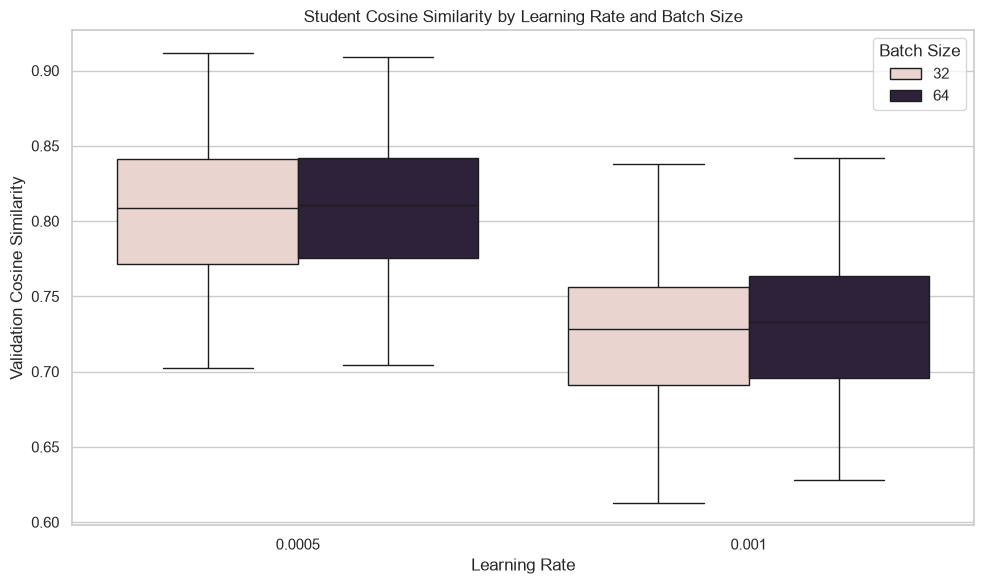

2026-08-01 03:39:27,802 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-01 03:39:27,804 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


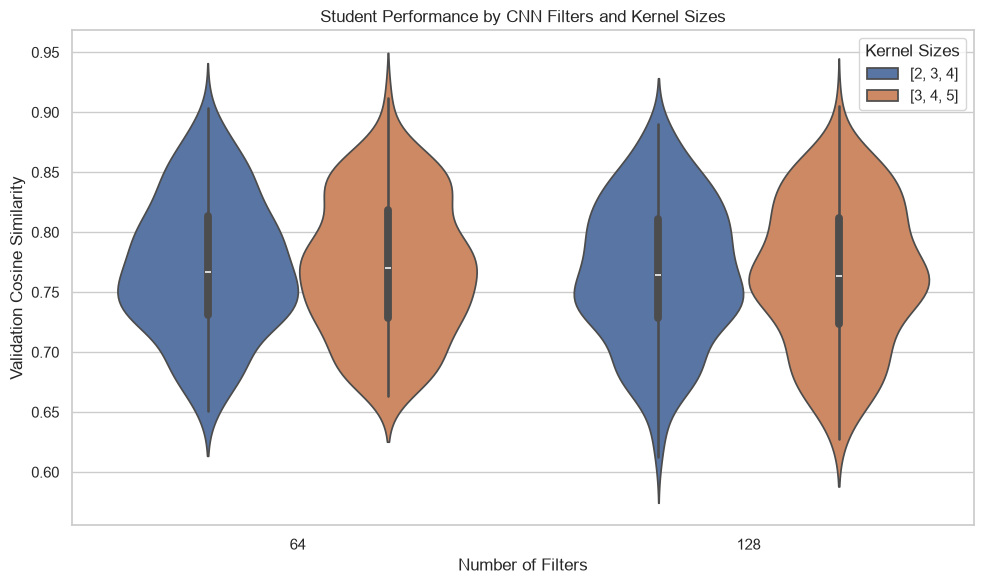

/var/folders/lp/zwhx9c_s7lnc0l7zc5160jn80000gn/T/ipykernel_2230/3926367938.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


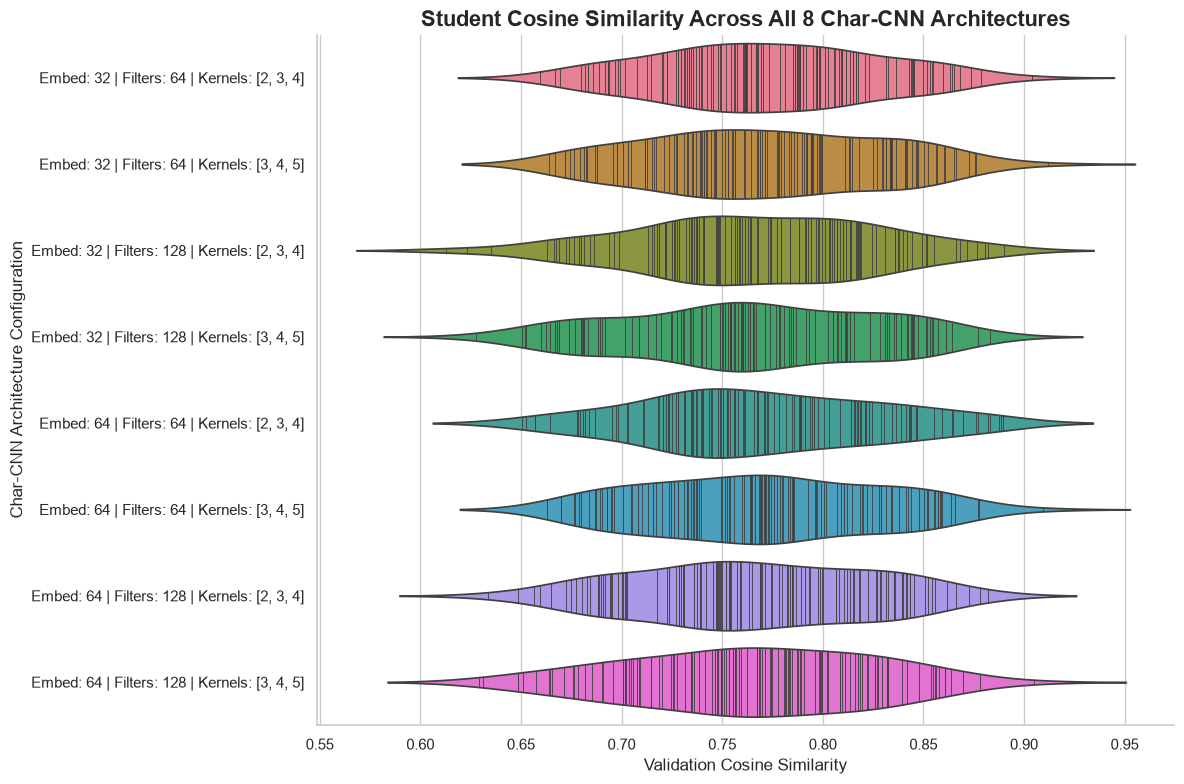

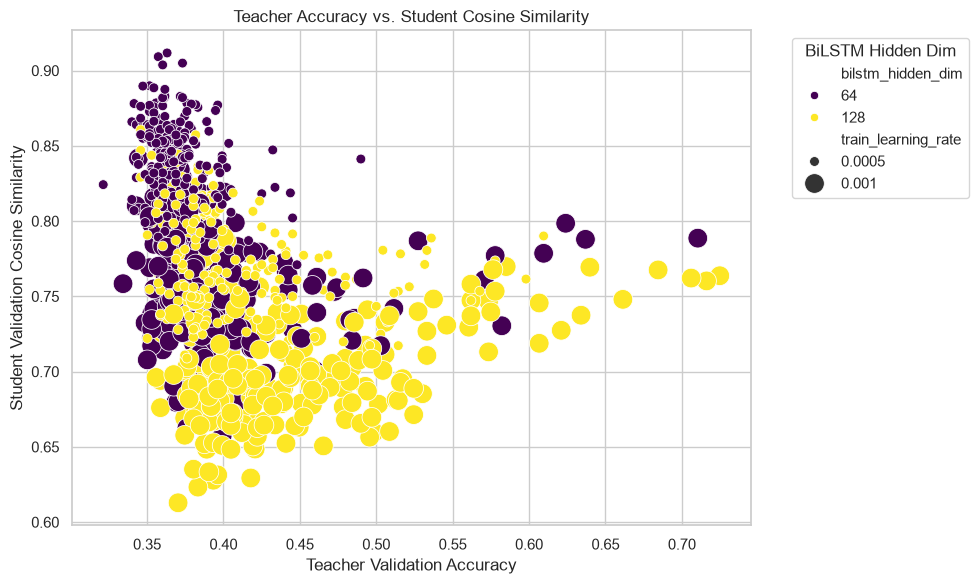

🏆 TOP 5 'MIDDLE GROUND' CONFIGURATIONS 🏆

 teacher_val_acc  student_val_sim  balance_score  train_learning_rate  train_batch_size  bilstm_hidden_dim  charcnn_embed_dim  charcnn_num_filters charcnn_kernel_sizes
        0.710375         0.788661       0.560245                0.001                32                 64                 64                   64            [2, 3, 4]
        0.724784         0.763697       0.553515                0.001                64                128                 32                  128            [2, 3, 4]
        0.716138         0.760258       0.544450                0.001                64                128                 32                   64            [2, 3, 4]
        0.706052         0.762151       0.538118                0.001                32                128                 64                  128            [3, 4, 5]
        0.684438         0.767551       0.525341                0.001                64                128            

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the relative path to the results file
file_path = "results/tuning_results.json"

# Load the JSON data
with open(file_path, "r") as f:
    results = json.load(f)

# Flatten the nested dictionaries so Pandas and Seaborn can process them
flattened_data = []
for row in results:
    flat_row = {}
    
    # Flatten BiLSTM configs
    for key, value in row["bilstm_config"].items():
        flat_row[f"bilstm_{key}"] = value
        
    # Flatten CharCNN configs (convert kernel lists to strings for grouping)
    for key, value in row["charcnn_config"].items():
        flat_row[f"charcnn_{key}"] = str(value) if isinstance(value, list) else value
        
    # Flatten Training configs
    for key, value in row["training_config"].items():
        flat_row[f"train_{key}"] = value
        
    # Extract Validation Metrics (Index 1 from the lists based on PyTorch norms)
    flat_row["teacher_val_acc"] = row["teacher_accuracy"][1]
    flat_row["student_val_sim"] = row["student_cosine_similarity"][1]
    
    flattened_data.append(flat_row)

# Create a Pandas DataFrame
df = pd.DataFrame(flattened_data)

# Set global visualization style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Graph 1: The Impact of Learning Rate and Batch Size
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="train_learning_rate", y="student_val_sim", hue="train_batch_size")
plt.title("Student Cosine Similarity by Learning Rate and Batch Size")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Cosine Similarity")
plt.legend(title="Batch Size")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Graph 2: Char-CNN Architecture Impact
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="charcnn_num_filters", y="student_val_sim", hue="charcnn_kernel_sizes")
plt.title("Student Performance by CNN Filters and Kernel Sizes")
plt.xlabel("Number of Filters")
plt.ylabel("Validation Cosine Similarity")
plt.legend(title="Kernel Sizes")
plt.tight_layout()
plt.show()
# 1. Create a new column that combines all Char-CNN architecture settings into one string
df["charcnn_architecture"] = (
    "Embed: " + df["charcnn_embed_dim"].astype(str) + 
    " | Filters: " + df["charcnn_num_filters"].astype(str) + 
    " | Kernels: " + df["charcnn_kernel_sizes"]
)

# Set the global style
sns.set_theme(style="whitegrid")

# We use a catplot with kind="violin" to assign a distinct color palette 
# to every single architectural combination.
g = sns.catplot(
    data=df, 
    x="student_val_sim", 
    y="charcnn_architecture", 
    kind="violin", 
    palette="husl",  # 'husl' generates evenly spaced, highly distinct colors
    height=8, 
    aspect=1.5,
    inner="stick"    # Shows every individual data point inside the violin
)

plt.title("Student Cosine Similarity Across All 8 Char-CNN Architectures", fontsize=16, weight="bold")
plt.xlabel("Validation Cosine Similarity", fontsize=12)
plt.ylabel("Char-CNN Architecture Configuration", fontsize=12)

# Adjust layout so the long Y-axis labels aren't cut off
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Graph 3: Teacher Accuracy vs. Student Similarity
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x="teacher_val_acc", 
    y="student_val_sim", 
    hue="bilstm_hidden_dim", 
    size="train_learning_rate", 
    palette="viridis",
    sizes=(50, 200)
)
plt.title("Teacher Accuracy vs. Student Cosine Similarity")
plt.xlabel("Teacher Validation Accuracy")
plt.ylabel("Student Validation Cosine Similarity")
# Move legend outside the plot area
plt.legend(title="BiLSTM Hidden Dim", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 1. Calculate a 'Balance Score' (Teacher Accuracy * Student Similarity)
# This rewards models that perform reasonably well on BOTH metrics.
df["balance_score"] = df["teacher_val_acc"] * df["student_val_sim"]

# 2. Sort the DataFrame to find the top 5 highest balance scores
top_5_balanced = df.sort_values(by="balance_score", ascending=False).head(5)

# 3. Define the exact columns we want to inspect
columns_to_show = [
    "teacher_val_acc", 
    "student_val_sim", 
    "balance_score",
    "train_learning_rate", 
    "train_batch_size",
    "bilstm_hidden_dim", 
    "charcnn_embed_dim",
    "charcnn_num_filters", 
    "charcnn_kernel_sizes"
]

# 4. Display the results cleanly
print("🏆 TOP 5 'MIDDLE GROUND' CONFIGURATIONS 🏆\n")
print(top_5_balanced[columns_to_show].to_string(index=False))

## Suggested Hyperparameters
- learning rate: 0.001
- batch size 64
- [2, 3, 4] kernel trio
- number of filters 64
- embed-dim 64 (CNN)
- hidden dim 64 (BiLSTM)

## The Turning Point: Balancing Accuracy and Mimicry

Initially, looking at the standalone distributions, it seemed like a slower learning rate (0.0005) was the safer choice for ensuring the Student model could mimic the Teacher. However, our perspective completely shifted when we mapped Teacher Validation Accuracy against Student Cosine Similarity and calculated a combined "Balance Score."

The final scatter plot and the Top 5 configurations table revealed that focusing only on the student's mimicry was a trap. We needed a "Goldilocks" model—a teacher smart enough to catch the spelling mistakes, paired with a student capable of copying it.

Here is why your suggested parameters are the winning combination:

**Learning Rate: 0.001**

While 0.0005 created slightly tighter student similarity overall, the Top 5 table proved that a learning rate of 0.001 is essential. The slower rate prevented the Teacher model from learning effectively. By bumping the learning rate to 0.001, the Teacher achieved a much higher validation accuracy (~71%) while the Student was still able to maintain an impressive ~79% similarity score.

**BiLSTM Hidden Dim: 64**

The scatter plot clearly exposed a capacity bottleneck. When the Teacher used a hidden dimension of 128 (the yellow dots), its internal logic became too complex for the lightweight Char-CNN to reverse-engineer, causing student similarity to plummet. A hidden dimension of 64 (the purple dots) kept the Teacher's mathematical space simple enough for the Student to successfully map and mimic, earning the #1 spot in our balanced table.

**Char-CNN Embed-Dim: 64**

Pairing the Teacher's 64 hidden dimension with a Student embedding dimension of 64 provided the perfect 1:1 input-to-output capacity ratio. It gave the Student just enough numerical detail to understand the characters without wasting memory or overfitting.

**Kernel Trio: [2, 3, 4]**

As confirmed by the top 3 spots in the final table, this tighter sliding window is perfectly engineered for your dataset. Because elementary spelling errors typically occur in short words and revolve around small phonetic mistakes (like swapping "ie" for "ei"), a kernel size of 2 or 3 catches these micro-errors perfectly. Larger kernels (like 5) would overshoot the length of many elementary words entirely.

**Number of Filters: 64**

Looking back at our earlier violin plots, the distributions for 64 filters and 128 filters were nearly identical. Because 128 filters did not provide a massive overall change or distinct advantage in the visual spread, 64 is the superior choice. It forces the model to learn only the most important spelling rules, prevents memorization of noisy data, and keeps training times highly efficient.

**Batch Size: 64**

A quick, candid note: Your absolute #1 model in the table actually used a batch size of 32! However, choosing 64 is still a highly strategic and valid decision. Batch size 64 claimed the #2, #3, and #5 spots in your balanced top performers. Because the previous boxplots showed that batch sizes of 32 and 64 perform almost identically at optimal learning rates, using 64 will give you that same top-tier performance while taking significantly better advantage of your GPU to train faster.